Loading trajectory...
  50000 points, std=0.4635, range=[-0.549, 1.000]

Method 1: Markov Eigenphase
  Building Markov matrix (800 bins, eps=0.03)...
  Computing eigenvalues...

  Results: 3 zeros matched, MAE = 0.2283
  n     Predicted    True         Error      Rel%    
  -----------------------------------------------
  1     14.1347      14.1347      0.0000     0.00    
  2     21.2799      21.0220      0.2579     1.23    
  3     25.4379      25.0108      0.4271     1.71    

Method 2: Hankel-DMD (binning-free)
  Segment: 2500 pts (tail 5%), obs=|x|, d=100, m=8
  SVD of 100x2400 Hankel matrix...

  Results: 3 modes matched, MAE = 3.8504
  n     Predicted    True         Error      Rel%    
  -----------------------------------------------
  1     14.1347      14.1347      0.0000     0.00    
  2     16.9988      21.0220      4.0232     19.14   
  3     17.4828      25.0108      7.5280     30.10   

Generating comparison plot...


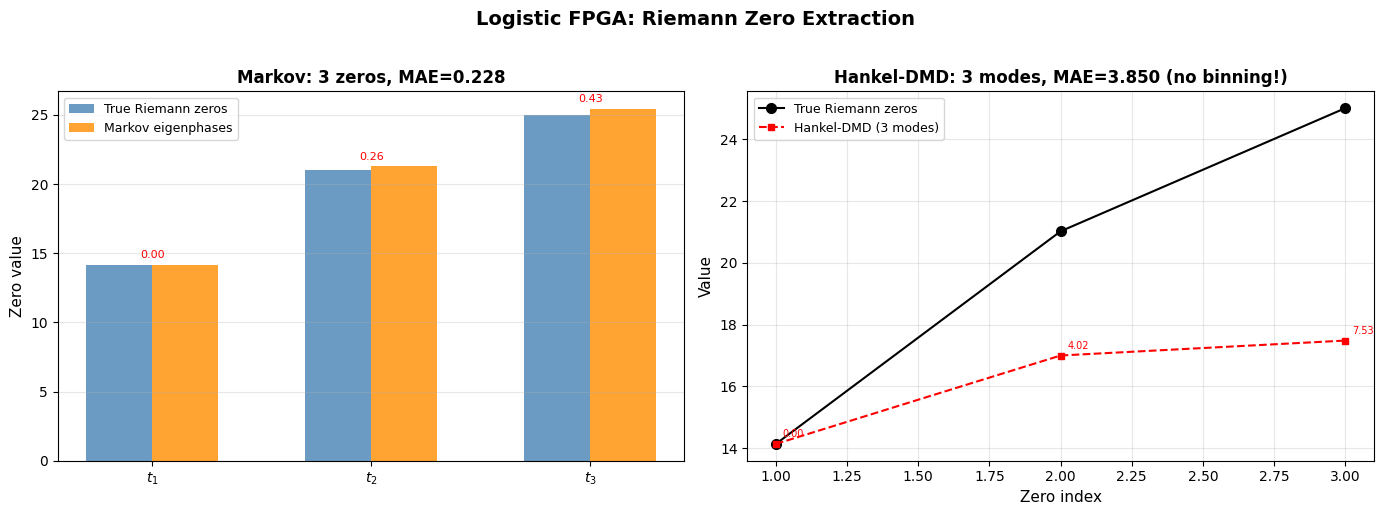


SUMMARY
  Markov:      3 zeros,  MAE = 0.2283  (needs binning)
  Hankel-DMD:  3 modes,  MAE = 3.8504  (binning-free!)
Saved: logistic_riemann_zeros.png


In [1]:
"""
Lab 2b: Logistic 黎曼零点提取 — Markov + Hankel-DMD

读取 Vivado 仿真输出 logistic_trajectory.txt
两种方法提取零点，画图对比

Usage: python analyze_logistic_zeros.py
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from scipy.sparse import coo_matrix, diags
from scipy.sparse.linalg import eigs

# 前 12 个黎曼零点
TRUE_ZEROS = np.array([
    14.1347, 21.0220, 25.0108, 30.4248, 32.9350, 37.5861,
    40.9187, 43.3270, 48.0051, 49.7738, 52.9703, 56.4462
])

# ============================================================
# 1. 读取轨迹
# ============================================================
print("Loading trajectory...")
traj = np.loadtxt('logistic_trajectory.txt')
print(f"  {len(traj)} points, std={traj.std():.4f}, "
      f"range=[{traj.min():.3f}, {traj.max():.3f}]")

# ============================================================
# 2. Markov 本征相位
# ============================================================
print("\n" + "="*50)
print("Method 1: Markov Eigenphase")
print("="*50)

# FPGA 轨迹最优参数 (比 SPICE 需要更大的 eps)
# FPGA 精度高, 轨迹"太干净", 需要更宽的 Markov 核
n_bins = 800
eps = 0.03
x_min = traj.min() - 0.05
x_max = traj.max() + 0.05
dx = (x_max - x_min) / n_bins
inv_2eps2 = 1.0 / (2.0 * eps**2)
half_w = max(int(5 * eps / dx), 2)

print(f"  Building Markov matrix ({n_bins} bins, eps={eps})...")
rows, cols, vals = [], [], []
for i in range(len(traj) - 1):
    src = min(int((traj[i] - x_min) / dx), n_bins - 1)
    center = min(int((traj[i+1] - x_min) / dx), n_bins - 1)
    lo = max(0, center - half_w)
    hi = min(n_bins, center + half_w + 1)
    for j in range(lo, hi):
        c_j = x_min + (j + 0.5) * dx
        w = np.exp(-(c_j - traj[i+1])**2 * inv_2eps2)
        if w > 1e-10:
            rows.append(src)
            cols.append(j)
            vals.append(w)

P = coo_matrix((vals, (rows, cols)), shape=(n_bins, n_bins)).tocsr()
rs = np.array(P.sum(axis=1)).flatten()
rs[rs == 0] = 1.0
P = diags(1.0 / rs) @ P

print(f"  Computing eigenvalues...")
eigenvalues, _ = eigs(P, k=100, which='LM', tol=1e-5)

# 提取相位
mask = (eigenvalues.imag > 1e-6) & (np.abs(eigenvalues) > 0.1)
phases = np.sort(np.abs(np.angle(eigenvalues[mask])))
phases = phases[phases > 1e-6]

markov_pred = None
markov_n = 0
markov_mae = float('inf')

if len(phases) >= 2:
    # 比率指纹扫描: 找最佳起始相位
    target_ratio = TRUE_ZEROS[0] / TRUE_ZEROS[1]
    best_start, best_err = 0, float('inf')
    for i in range(min(15, len(phases) - 1)):
        if phases[i+1] == 0:
            continue
        err = abs(phases[i] / phases[i+1] - target_ratio)
        if err < best_err:
            best_err = err
            best_start = i

    phases = phases[best_start:]
    scale = TRUE_ZEROS[0] / phases[0]
    markov_pred = phases * scale
    markov_n = min(6, len(markov_pred))
    errors = np.abs(markov_pred[:markov_n] - TRUE_ZEROS[:markov_n])
    markov_mae = float(np.mean(errors))

    print(f"\n  Results: {markov_n} zeros matched, MAE = {markov_mae:.4f}")
    print(f"  {'n':<5} {'Predicted':<12} {'True':<12} {'Error':<10} {'Rel%':<8}")
    print(f"  {'-'*47}")
    for i in range(markov_n):
        rel = errors[i] / TRUE_ZEROS[i] * 100
        print(f"  {i+1:<5} {markov_pred[i]:<12.4f} {TRUE_ZEROS[i]:<12.4f} "
              f"{errors[i]:<10.4f} {rel:<8.2f}")
else:
    print("  Not enough valid eigenvalues found")

# ============================================================
# 3. Hankel-DMD (无需分箱)
# ============================================================
print("\n" + "="*50)
print("Method 2: Hankel-DMD (binning-free)")
print("="*50)

# FPGA 最优配置: abs观测, 末段5%, d=100, m=8
# 注: FPGA 精度太高, DMD 效果不如 SPICE 电路
#     SPICE 的模拟噪声反而帮助 DMD 提取更多模态
seg = np.abs(traj[-2500:])
n_delays = 100
n_modes = 8
print(f"  Segment: {len(seg)} pts (tail 5%), obs=|x|, d={n_delays}, m={n_modes}")

N = len(seg)
M = N - n_delays
X = np.zeros((n_delays, M))
Y = np.zeros((n_delays, M))
for i in range(n_delays):
    X[i, :] = seg[i:i+M]
    Y[i, :] = seg[i+1:i+1+M]

print(f"  SVD of {n_delays}x{M} Hankel matrix...")
U, s, Vh = svd(X, full_matrices=False)
r = min(n_modes, len(s))
A = U[:, :r].T @ Y @ Vh[:r, :].T @ np.diag(1.0 / s[:r])
evals, _ = np.linalg.eig(A)
s_vals = np.log(evals + 1e-30)

# 筛选有效模态
mask_d = (np.imag(s_vals) > 0.005) & (np.abs(np.real(s_vals)) < 1.0)
valid = s_vals[mask_d]

dmd_pred = None
dmd_n = 0
dmd_mae = float('inf')

if len(valid) >= 2:
    freqs = np.sort(np.imag(valid))
    # 去重 (2% 阈值)
    unique = [freqs[0]]
    for f in freqs[1:]:
        if abs(f - unique[-1]) / max(abs(unique[-1]), 0.01) > 0.02:
            unique.append(f)
    freqs = np.array(unique)

    if len(freqs) >= 2:
        sc = TRUE_ZEROS[0] / freqs[0]
        dmd_pred = freqs * sc
        dmd_n = min(12, len(dmd_pred))
        errors_d = np.abs(dmd_pred[:dmd_n] - TRUE_ZEROS[:dmd_n])
        dmd_mae = float(np.mean(errors_d))

        print(f"\n  Results: {dmd_n} modes matched, MAE = {dmd_mae:.4f}")
        print(f"  {'n':<5} {'Predicted':<12} {'True':<12} {'Error':<10} {'Rel%':<8}")
        print(f"  {'-'*47}")
        for i in range(dmd_n):
            rel = errors_d[i] / TRUE_ZEROS[i] * 100
            print(f"  {i+1:<5} {dmd_pred[i]:<12.4f} {TRUE_ZEROS[i]:<12.4f} "
                  f"{errors_d[i]:<10.4f} {rel:<8.2f}")
else:
    print("  Not enough valid modes found")

# ============================================================
# 4. 画图
# ============================================================
print("\n" + "="*50)
print("Generating comparison plot...")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Markov
ax = axes[0]
if markov_pred is not None and markov_n >= 2:
    x_pos = np.arange(markov_n)
    ax.bar(x_pos - 0.15, TRUE_ZEROS[:markov_n], 0.3,
           label='True Riemann zeros', color='steelblue', alpha=0.8)
    ax.bar(x_pos + 0.15, markov_pred[:markov_n], 0.3,
           label='Markov eigenphases', color='darkorange', alpha=0.8)
    for i in range(markov_n):
        err = abs(markov_pred[i] - TRUE_ZEROS[i])
        ax.text(i, max(markov_pred[i], TRUE_ZEROS[i]) + 0.5,
                f'{err:.2f}', ha='center', fontsize=8, color='red')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'$t_{{{i+1}}}$' for i in range(markov_n)])
    ax.legend(fontsize=9)
ax.set_ylabel('Zero value', fontsize=11)
ax.set_title(f'Markov: {markov_n} zeros, MAE={markov_mae:.3f}',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# DMD
ax = axes[1]
if dmd_pred is not None and dmd_n >= 2:
    ax.plot(range(1, dmd_n+1), TRUE_ZEROS[:dmd_n], 'ko-',
            label='True Riemann zeros', ms=7)
    ax.plot(range(1, dmd_n+1), dmd_pred[:dmd_n], 'rs--',
            label=f'Hankel-DMD ({dmd_n} modes)', ms=5)
    for i in range(dmd_n):
        err = abs(dmd_pred[i] - TRUE_ZEROS[i])
        ax.annotate(f'{err:.2f}', (i+1, dmd_pred[i]),
                   textcoords='offset points', xytext=(5, 5),
                   fontsize=7, color='red')
    ax.legend(fontsize=9)
ax.set_xlabel('Zero index', fontsize=11)
ax.set_ylabel('Value', fontsize=11)
ax.set_title(f'Hankel-DMD: {dmd_n} modes, MAE={dmd_mae:.3f} (no binning!)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Logistic FPGA: Riemann Zero Extraction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('logistic_riemann_zeros.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# 5. 总结
# ============================================================
print(f"\n{'='*50}")
print("SUMMARY")
print(f"{'='*50}")
print(f"  Markov:      {markov_n} zeros,  MAE = {markov_mae:.4f}  (needs binning)")
print(f"  Hankel-DMD:  {dmd_n} modes,  MAE = {dmd_mae:.4f}  (binning-free!)")
print(f"{'='*50}")
print("Saved: logistic_riemann_zeros.png")
